In [73]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import joblib

In [74]:
df = pd.read_csv("../data/processed/processed_jobs.csv")

df.head()

,clean_text,telecommuting,has_company_logo,has_questions,fraudulent
0,marketing intern food weve created groundbreak...,0,1,0,0
1,customer service cloud video production second...,0,1,0,0
2,commissioning machinery assistant cma valor se...,0,1,0,0
3,account executive washington dc passion improv...,0,1,0,0
4,review manager spotsource solutions llc global...,0,1,1,0


In [99]:
X_text = df["clean_text"]

X_structured = df[
    [
        "telecommuting",
        "has_company_logo",
        "has_questions"
    ]
]

y = df["fraudulent"]

In [76]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X_text_tfidf = tfidf.fit_transform(X_text)

In [77]:
from scipy.sparse import hstack

In [78]:
X = hstack([
    X_text_tfidf,
    X_structured.values
])

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [81]:
lr_pred = lr_model.predict(X_test)

In [82]:
print("Accuracy:")

print(accuracy_score(y_test, lr_pred))

Accuracy:
0.9574944071588367


In [83]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      3403
           1       0.54      0.92      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.94      0.83      3576
weighted avg       0.97      0.96      0.96      3576



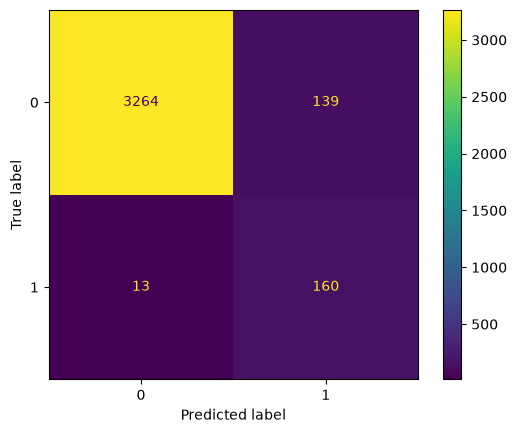

In [84]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.show()

In [85]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [86]:
print("Naive Bayes Accuracy")

print(accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy
0.9630872483221476
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3403
           1       0.71      0.40      0.51       173

    accuracy                           0.96      3576
   macro avg       0.84      0.70      0.75      3576
weighted avg       0.96      0.96      0.96      3576



In [87]:
joblib.dump(
    lr_model,
    "../models/logistic_model.pkl"
)

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']

In [88]:
print(accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

0.9630872483221476
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3403
           1       0.71      0.40      0.51       173

    accuracy                           0.96      3576
   macro avg       0.84      0.70      0.75      3576
weighted avg       0.96      0.96      0.96      3576



In [89]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, lr_pred))

[[3264  139]
 [  13  160]]


In [90]:
import joblib

joblib.dump(X_test, "../models/X_test.pkl")
joblib.dump(y_test, "../models/y_test.pkl")

print("Test data saved successfully.")

Test data saved successfully.


In [91]:
import joblib

X_test = joblib.load("../models/X_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

print(type(X_test))
print(type(y_test))
print(X_test.shape)
print(y_test.shape)

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.Series'>
(3576, 5003)
(3576,)


In [92]:
import joblib

joblib.dump(X_test, "../models/X_test.pkl")
joblib.dump(y_test, "../models/y_test.pkl")

print("✅ X_test and y_test saved successfully.")

✅ X_test and y_test saved successfully.


In [93]:
import joblib

X_test = joblib.load("../models/X_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

print(type(X_test))
print(type(y_test))
print(X_test.shape)
print(y_test.shape)

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.Series'>
(3576, 5003)
(3576,)


In [ ]:
if "df_original" not in globals():
    df_original = pd.read_csv("../data/raw/fake_job_postings.csv")

fake_jobs = df_original[df_original["fraudulent"] == 1]

sample = fake_jobs.sample(1, random_state=42)

sample[
    [
        "title",
        "company_profile",
        "description",
        "requirements",
        "benefits",
        "telecommuting",
        "has_company_logo",
        "has_questions"
    ]
]

,title,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions
17789,customer service rep,NaN,customer service reps needed asap,NaN,will explain on phone interview,0,0,1


In [95]:
print(df.columns.tolist())

['clean_text', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']


In [96]:
import pandas as pd

df_original = pd.read_csv("../data/raw/fake_job_postings.csv")
df_original.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

In [98]:
fake_jobs = df_original[df_original["fraudulent"] == 1]

sample = fake_jobs.sample(1, random_state=42)

sample[[
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]]


,title,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions
17789,customer service rep,NaN,customer service reps needed asap,NaN,will explain on phone interview,0,0,1
